<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Time_Series_Forecasting_using_Feed_Forward_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
from google.colab import files
import io
uploaded = files.upload()

Saving AirPassengers.csv to AirPassengers.csv


In [4]:
dataframe = pd.read_csv(io.BytesIO(uploaded['AirPassengers.csv']), usecols=[1])
print(dataframe.head())

   #Passengers
0          112
1          118
2          132
3          129
4          121


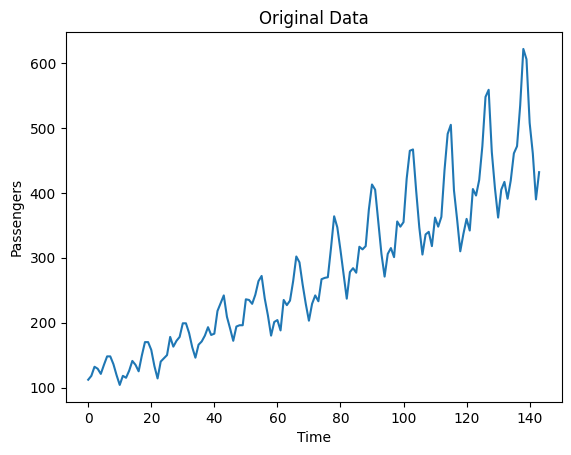

In [5]:
plt.plot(dataframe)
plt.title('Original Data')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.show()

In [10]:
dataset = dataframe.values.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)
print(dataset[:5])

[[0.01544401]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


In [33]:
train_size = int(len(dataset) * 0.66)
train, test = dataset[:train_size], dataset[train_size:]

In [17]:
def to_sequences(dataset, seq_size=1):
    x, y = [], []
    for i in range(len(dataset) - seq_size - 1):
        window = dataset[i:(i + seq_size), 0]
        x.append(window)
        y.append(dataset[i + seq_size, 0])
    return np.array(x), np.array(y)

seq_size = 10
trainX, trainY = to_sequences(train, seq_size)
testX, testY = to_sequences(test, seq_size)

print("Shape of training set:", trainX.shape)
print("Shape of test set:", testX.shape)

Shape of training set: (84, 10)
Shape of test set: (38, 10)


### 🔹 Summary:

1. **Purpose**:
   Converts time-series data into input-output pairs for prediction.

2. **Input**:

   * `dataset`: 1D data (like monthly passengers)
   * `seq_size`: Number of past time steps to use (e.g., 10)

3. **Output**:

   * `x`: Sequences of `seq_size` past values
   * `y`: The next value after each sequence

4. **How it works**:
   For every position `i` in the dataset:

   * `x = dataset[i : i + seq_size]`
   * `y = dataset[i + seq_size]`

5. **Use**:
   Feeds time-based input to the model so it can learn to predict the next value.

6. **Example** (with `seq_size = 3`):
   Input: `[10, 20, 30]` → Output: `40`



In [18]:
model = Sequential()
model.add(Dense(64, input_dim=seq_size, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
model.fit(trainX, trainY, validation_data=(testX, testY), epochs=100, verbose=2)

Epoch 1/100
3/3 - 2s - 736ms/step - loss: 0.2039 - mae: 0.3910 - val_loss: 0.9763 - val_mae: 0.9667
Epoch 2/100
3/3 - 0s - 87ms/step - loss: 0.1390 - mae: 0.3169 - val_loss: 0.6825 - val_mae: 0.8030
Epoch 3/100
3/3 - 0s - 85ms/step - loss: 0.0923 - mae: 0.2516 - val_loss: 0.4611 - val_mae: 0.6524
Epoch 4/100
3/3 - 0s - 31ms/step - loss: 0.0583 - mae: 0.1935 - val_loss: 0.2910 - val_mae: 0.5079
Epoch 5/100
3/3 - 0s - 34ms/step - loss: 0.0335 - mae: 0.1395 - val_loss: 0.1692 - val_mae: 0.3728
Epoch 6/100
3/3 - 0s - 47ms/step - loss: 0.0188 - mae: 0.0974 - val_loss: 0.0899 - val_mae: 0.2482
Epoch 7/100
3/3 - 0s - 45ms/step - loss: 0.0100 - mae: 0.0701 - val_loss: 0.0469 - val_mae: 0.1525
Epoch 8/100
3/3 - 0s - 31ms/step - loss: 0.0068 - mae: 0.0636 - val_loss: 0.0288 - val_mae: 0.1260
Epoch 9/100
3/3 - 0s - 46ms/step - loss: 0.0063 - mae: 0.0676 - val_loss: 0.0239 - val_mae: 0.1269
Epoch 10/100
3/3 - 0s - 30ms/step - loss: 0.0073 - mae: 0.0741 - val_loss: 0.0233 - val_mae: 0.1317
Epoch 11

In [34]:
testPredict = model.predict(testX)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step 


In [35]:
testPredict = scaler.inverse_transform(testPredict)
testY_inverse = scaler.inverse_transform([testY])

In [36]:
test_rmse = math.sqrt(mean_squared_error(testY_inverse[0], testPredict[:, 0]))
test_mae = mean_absolute_error(testY_inverse[0], testPredict[:, 0])
test_r2 = r2_score(testY_inverse[0], testPredict[:, 0])
def regression_accuracy(y_true, y_pred):
    return 100 - (np.mean(np.abs(y_pred - y_true) / y_true) * 100)
test_acc = regression_accuracy(testY_inverse[0], testPredict[:, 0])
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Accuracy (approx): {test_acc:.2f}%")

Test RMSE: 24.46
Test MAE: 20.06
Test R² Score: 0.9085
Test Accuracy (approx): 95.30%


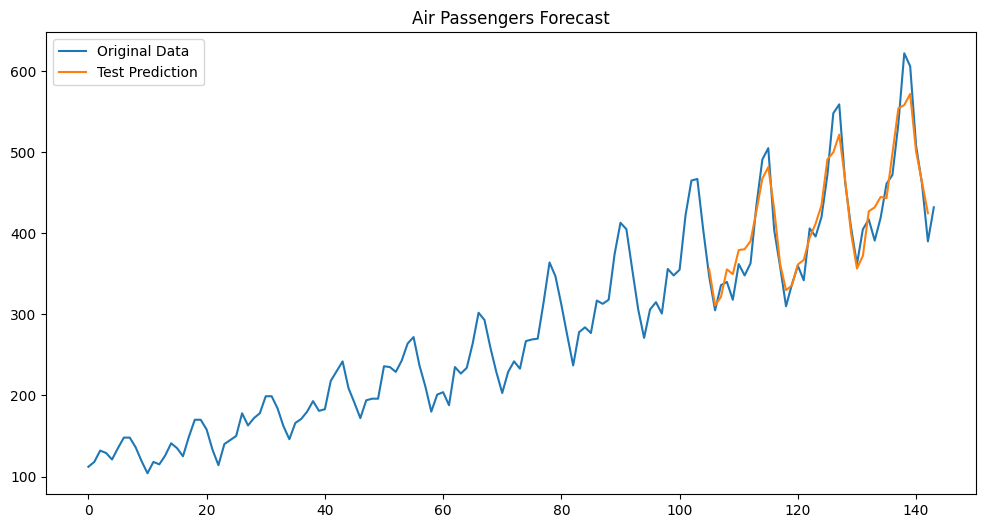

In [37]:
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict) + (seq_size * 2) + 1:len(dataset) - 1, :] = testPredict

plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(dataset), label='Original Data')
plt.plot(testPredictPlot, label='Test Prediction')
plt.legend()
plt.title("Air Passengers Forecast")
plt.show()

In [28]:
def predict_future(model, data, n_future, seq_size, scaler):
    future_predictions = []
    last_sequence = data[-seq_size:].reshape(1, seq_size)
    for _ in range(n_future):
        pred = model.predict(last_sequence, verbose=0)
        future_predictions.append(pred[0, 0])
        last_sequence = np.append(last_sequence[:, 1:], [[pred[0][0]]], axis=1)


    future_predictions = np.array(future_predictions).reshape(-1, 1)
    return scaler.inverse_transform(future_predictions)

n_future = 24
future_preds = predict_future(model, dataset, n_future, seq_size, scaler)

In [30]:
last_date = pd.to_datetime('1949-01') + pd.DateOffset(months=len(dataset))
future_dates = pd.date_range(last_date, periods=n_future, freq='MS')
future_df = pd.DataFrame({'Month': future_dates, 'Predicted Passengers': future_preds.flatten().round()})
print(future_df)

        Month  Predicted Passengers
0  1961-01-01                 450.0
1  1961-02-01                 453.0
2  1961-03-01                 501.0
3  1961-04-01                 523.0
4  1961-05-01                 562.0
5  1961-06-01                 628.0
6  1961-07-01                 633.0
7  1961-08-01                 600.0
8  1961-09-01                 513.0
9  1961-10-01                 466.0
10 1961-11-01                 460.0
11 1961-12-01                 481.0
12 1962-01-01                 494.0
13 1962-02-01                 529.0
14 1962-03-01                 561.0
15 1962-04-01                 583.0
16 1962-05-01                 635.0
17 1962-06-01                 679.0
18 1962-07-01                 662.0
19 1962-08-01                 603.0
20 1962-09-01                 546.0
21 1962-10-01                 508.0
22 1962-11-01                 519.0
23 1962-12-01                 538.0


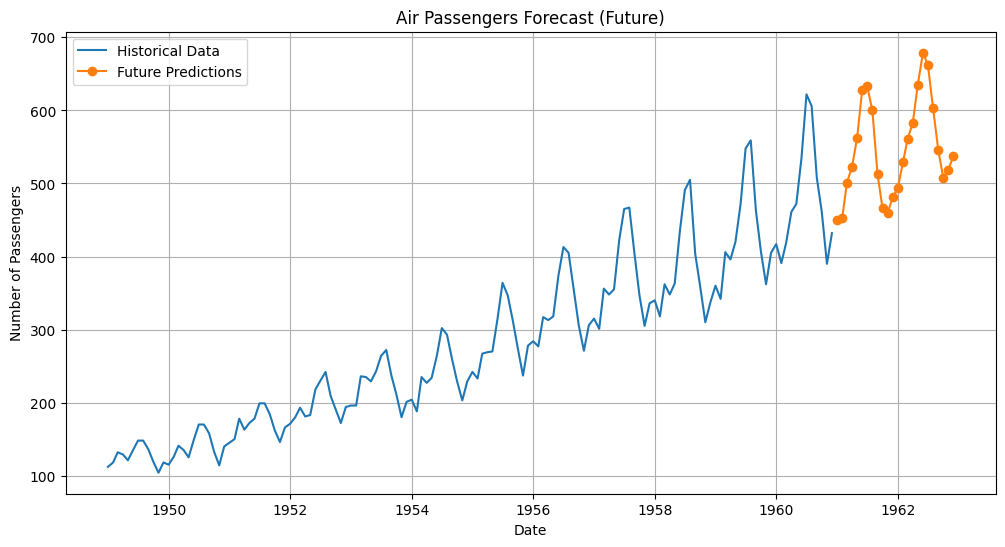

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(pd.date_range('1949-01', periods=len(dataset), freq='MS'), scaler.inverse_transform(dataset), label='Historical Data')
plt.plot(future_df['Month'], future_df['Predicted Passengers'], label='Future Predictions', marker='o')
plt.title('Air Passengers Forecast (Future)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

* Your feedforward network (FNN) doesn’t have memory like LSTM but works because:

  * You give it the **last 10 time steps as input** (sequence window), so it "sees" recent history.
  * This manual window acts like memory by showing past values explicitly.

* FNN works well for smooth, predictable, seasonal data (like airline passengers).

* LSTM models have **built-in memory** and are better for complex or long-term dependencies.

* Your FNN input shape is `(samples, seq_size)`, while LSTM needs `(samples, seq_size, features)`.

* You got good accuracy because your sliding window captures enough recent data for prediction.

